In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
movies=pd.read_csv('/content/drive/My Drive/ml-latest-small/movies.csv')
ratings=pd.read_csv('/content/drive/My Drive/ml-latest-small/ratings.csv')


In [21]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [22]:
movies.shape

(9742, 3)

In [23]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [24]:
ratings.shape

(100836, 4)

Merge them on movieid

In [25]:
movie_ratings = pd.merge(ratings, movies, on='movieId')


In [26]:
movie_ratings.head()


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [27]:
movie_ratings.shape

(100836, 6)

In [28]:
movie_ratings.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0
title,0
genres,0


In [29]:
movie_ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [30]:
movie_ratings.dtypes

,0
userId,int64
movieId,int64
rating,float64
timestamp,int64
title,object
genres,object


Separate Year from Title

In [31]:
movie_ratings['year'] = movie_ratings['title'].str.extract(r'\((\d{4})\)', expand=False)

movie_ratings['title'] = movie_ratings['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

movie_ratings['year'] = pd.to_numeric(movie_ratings['year'])

Convert Timestamp to Datetime

In [32]:
movie_ratings['timestamp'] = pd.to_datetime(movie_ratings['timestamp'], unit='s')

movie_ratings['rating_year'] = movie_ratings['timestamp'].dt.year


Handle the Genres (Split or Expand)

In [33]:
movie_ratings['genres'].value_counts()

,count
genres,
Comedy,7196
Drama,6291
Comedy|Romance,3967
Comedy|Drama|Romance,3000
Comedy|Drama,2851
...,...
Action|Adventure|Animation|Comedy|Fantasy|Mystery|Sci-Fi,1
Children|Fantasy|Musical|Romance,1
Comedy|Crime|Drama|Horror,1


In [34]:
# Create a matrix of genres
genre_columns = movie_ratings['genres'].str.get_dummies(sep='|')

movie_ratings = pd.concat([movie_ratings, genre_columns], axis=1)

In [35]:
movie_ratings.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0
title,0
genres,0
year,18
rating_year,0
(no genres listed),0
Action,0


In [36]:
no_genre_movies = movie_ratings[movie_ratings['genres'] == "(no genres listed)"]
print(no_genre_movies[['title', 'genres']].head())

                                                 title              genres
3624  Pirates of the Caribbean: Dead Men Tell No Tales  (no genres listed)
7353                                        La cravate  (no genres listed)
7408                              The Putin Interviews  (no genres listed)
9101  Pirates of the Caribbean: Dead Men Tell No Tales  (no genres listed)
9141                  The Godfather Trilogy: 1972-1990  (no genres listed)


In [37]:
movie_ratings = movie_ratings.dropna(subset=['year'])

In [38]:
movie_ratings['year'] =movie_ratings['year'].astype('int32')

In [39]:
movie_ratings = movie_ratings.drop(columns=['genres','timestamp'])


In [40]:
if '(no genres listed)' in movie_ratings.columns:
    movie_ratings = movie_ratings.drop(columns=['(no genres listed)'])



In [41]:
movie_ratings

,userId,movieId,rating,title,year,rating_year,Action,Adventure,Animation,Children,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1,4.0,Toy Story,1995,2000,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,3,4.0,Grumpier Old Men,1995,2000,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1,6,4.0,Heat,1995,2000,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,47,5.0,Seven (a.k.a. Se7en),1995,2000,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,1,50,5.0,"Usual Suspects, The",1995,2000,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100831,610,166534,4.0,Split,2017,2017,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
100832,610,168248,5.0,John Wick: Chapter Two,2017,2017,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
100833,610,168250,5.0,Get Out,2017,2017,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
100834,610,168252,5.0,Logan,2017,2017,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [42]:
movie_ratings.shape

(100818, 25)

Final "Sanity Check" for Problems

In [43]:
duplicates = movie_ratings.duplicated(subset=['userId', 'movieId']).sum()
print(f"Duplicate user-movie pairs: {duplicates}")

Duplicate user-movie pairs: 0


Analysis of data

A. Global Rating Distribution

/tmp/ipython-input-3474019800.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=movie_ratings, palette='magma')


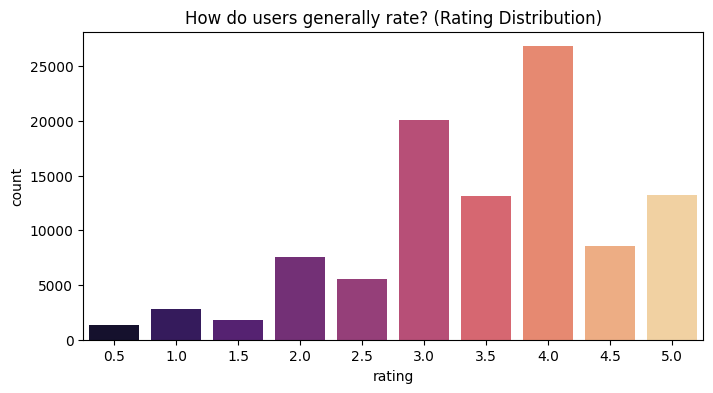

In [44]:
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=movie_ratings, palette='magma')
plt.title('How do users generally rate? (Rating Distribution)')
plt.show()

B. User Activity vs. Movie Popularity

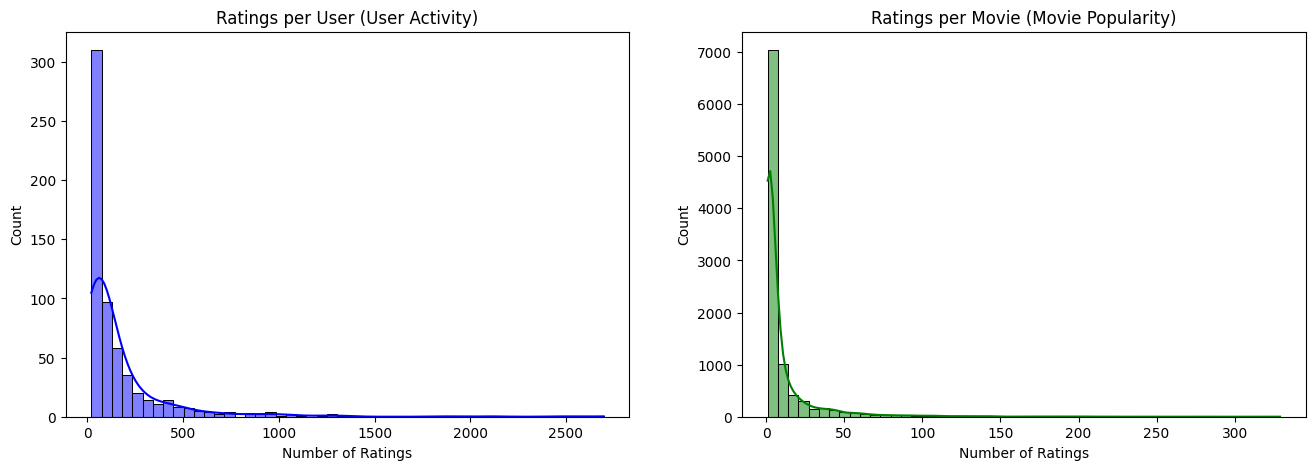

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Ratings per User
user_counts = movie_ratings.groupby('userId').size()
sns.histplot(user_counts, bins=50, ax=ax[0], kde=True, color='blue')
ax[0].set_title('Ratings per User (User Activity)')
ax[0].set_xlabel('Number of Ratings')

# Ratings per Movie
movie_counts = movie_ratings.groupby('movieId').size()
sns.histplot(movie_counts, bins=50, ax=ax[1], kde=True, color='green')
ax[1].set_title('Ratings per Movie (Movie Popularity)')
ax[1].set_xlabel('Number of Ratings')

plt.show()

The visualizations created by the analysis code act as a diagnostic map for your recommendation system, revealing the underlying structure and biases of your dataset. Specifically, the distribution plots show that your data is heavily skewed toward high ratings (a "positivity bias") and dominated by a "Long Tail" effect, where a small handful of blockbuster movies and power users account for the vast majority of interactions while thousands of others have very little data. By looking at the genre and yearly trends, you can see how average quality scores fluctuate across different categories—like Drama consistently outperforming Horror—and how user expectations have shifted over time. Ultimately, these images tell you that your matrix is highly sparse, meaning your model's primary challenge is not just calculating a score, but mathematically "guessing" the missing preferences for users who have only explored a tiny fraction of the available film library.

C. Average Rating per Genre

In [46]:
genres_list = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
               'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
               'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [47]:
genre_means = {}
for genre in genres_list:
    genre_means[genre] = movie_ratings[movie_ratings[genre] == 1]['rating'].mean()


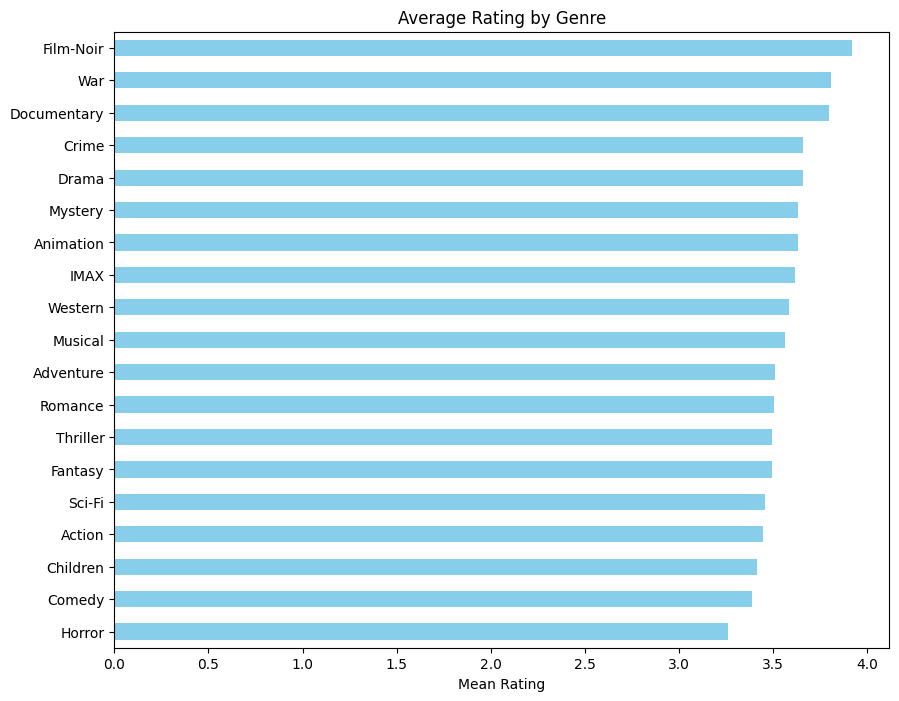

In [48]:
pd.Series(genre_means).sort_values().plot(kind='barh', figsize=(10, 8), color='skyblue')
plt.title('Average Rating by Genre')
plt.xlabel('Mean Rating')
plt.show()

D. Ratings Over Time (The "Hype" Factor)

Does the average rating change over the years?

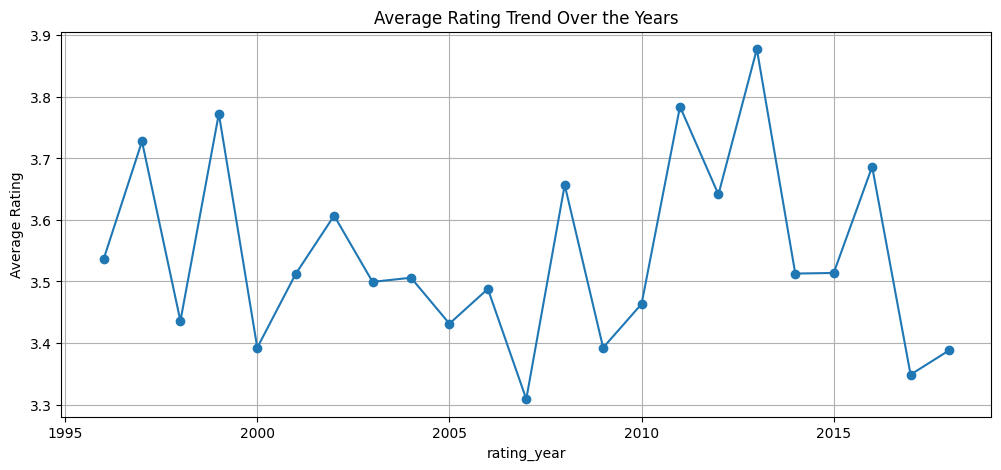

In [49]:
plt.figure(figsize=(12, 5))
movie_ratings.groupby('rating_year')['rating'].mean().plot(marker='o')
plt.title('Average Rating Trend Over the Years')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

The Final Step Before Modeling: Handling the "Cold Start"
Before we train the model, we have one critical problem: Sparsity.

If a movie has only been rated by 1 person, we don't know if that 5-star rating is because the movie is a masterpiece or because that one person has weird taste. Similarly, if a user has only rated 1 movie, we don't know their personality.

The Strategy: Filter your dataset to keep only "statistically significant" data.

In [50]:
print(f"Min ratings per user: {movie_ratings.groupby('userId')['rating'].count().min()}")
print(f"Min ratings per movie: {movie_ratings.groupby('movieId')['rating'].count().min()}")

Min ratings per user: 20
Min ratings per movie: 1


Yes, having a minimum of 1 rating per movie is a significant problem for a recommendation model. While your "Min ratings per user: 20" is excellent (it means you have enough history for every person), the movie side of your data is currently too "noisy."

In [51]:
# 1. Filter out movies with fewer than 10 ratings
movie_counts = movie_ratings.groupby('movieId').count()['rating']
popular_movies = movie_counts[movie_counts >= 10].index
df_filtered = movie_ratings[movie_ratings['movieId'].isin(popular_movies)]


In [52]:

# 2. Filter out users who have given fewer than 20 ratings
user_counts = df_filtered.groupby('userId').count()['rating']
active_users = user_counts[user_counts > 20].index
df_final = df_filtered[df_filtered['userId'].isin(active_users)]


In [53]:

print(f"Final dataset shape: {df_final.shape}")


Final dataset shape: (80408, 25)


In [54]:
print(f"Unique Users: {df_final['userId'].nunique()} | Unique Movies: {df_final['movieId'].nunique()}")

Unique Users: 571 | Unique Movies: 2269


In [55]:
!pip install scikit-surprise

Implementation (The Two-Model Approach)

In [56]:
from surprise import SVD, Reader, Dataset
from surprise.model_selection import train_test_split
from surprise import accuracy


In [57]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df_final[['userId', 'movieId', 'rating']], reader)


In [58]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)


In [59]:
svd_model = SVD()
svd_model.fit(trainset)


In [60]:
predictions_svd = svd_model.test(testset)

rmse_svd = accuracy.rmse(predictions_svd)

mae_svd = accuracy.mae(predictions_svd)



RMSE: 0.8518
MAE:  0.6531


In [61]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [62]:

genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']



In [63]:
X = df_final[genre_cols + ['year']]
y = df_final['rating']


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [65]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=12, n_jobs=-1, random_state=42)

In [66]:
rf_preds = rf_model.predict(X_test)


In [67]:
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
mae = mean_absolute_error(y_test, rf_preds)
r2 = r2_score(y_test, rf_preds)


In [73]:

print("--- RANDOM FOREST REGRESSOR RESULTS ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"R-Squared Score (R2):          {r2:.4f}")



--- RANDOM FOREST REGRESSOR RESULTS ---
Root Mean Squared Error (RMSE): 0.9491
Mean Absolute Error (MAE):     0.7463
R-Squared Score (R2):          0.1240


Checking

Random Forest Regressor

In [88]:
# --- 1. GET USER PREFERENCES ---
user_id = 100
print(f"Top 5 Movies previously rated by User {user_id}:")
user_history = df_final[df_final['userId'] == user_id]

if not user_history.empty:
    print(user_history[['title', 'rating']].sort_values(by='rating', ascending=False).head(5))
else:
    print(f"No history found for User {user_id}")

print("-" * 30)

Top 5 Movies previously rated by User 100:
                                                   title  rating
15425                        Officer and a Gentleman, An     5.0
15401  Christmas Vacation (National Lampoon's Christm...     5.0
15437                                 Sweet Home Alabama     5.0
15386                                Terms of Endearment     5.0
15355                                            Top Gun     5.0
------------------------------


In [89]:
# --- 2. PREDICT RATING FOR A NEW MOVIE ---
movie_name_input = "So I Married an Axe Murderer"
search = movies[movies['title'].str.contains(movie_name_input, case=False, na=False)]

if not search.empty:
    target_id = search.iloc[0]['movieId']
    target_title = search.iloc[0]['title']
    movie_features = df_final[df_final['movieId'] == target_id][genre_cols + ['year']].drop_duplicates()

    if not movie_features.empty:
        # Predict
        prediction = rf_model.predict(movie_features.values.reshape(1, -1))[0]
        print(f"Based on its genres, the model predicts User {user_id} would rate '{target_title}' as: {prediction:.2f} stars")
    else:
        print(f"Movie '{target_title}' was found, but it doesn't have enough ratings to be in our model features.")
else:
    print(f"Could not find a movie matching '{movie_name_input}'")

Based on its genres, the model predicts User 100 would rate 'So I Married an Axe Murderer (1993)' as: 3.46 stars


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [90]:
# 1. Define your IDs
uid = 100
iid = 543
try:
    movie_name = movies[movies['movieId'] == iid]['title'].values[0]
except IndexError:
    movie_name = "Unknown Movie (ID not found)"

# 3. Get the SVD prediction
pred = svd_model.predict(uid, iid)

# 4. Print the result with the movie name
print(f"--- SVD Recommendation ---")
print(f"User {uid} predicted rating for '{movie_name}': {pred.est:.2f} stars")

--- SVD Recommendation ---
User 100 predicted rating for 'So I Married an Axe Murderer (1993)': 3.57 stars
